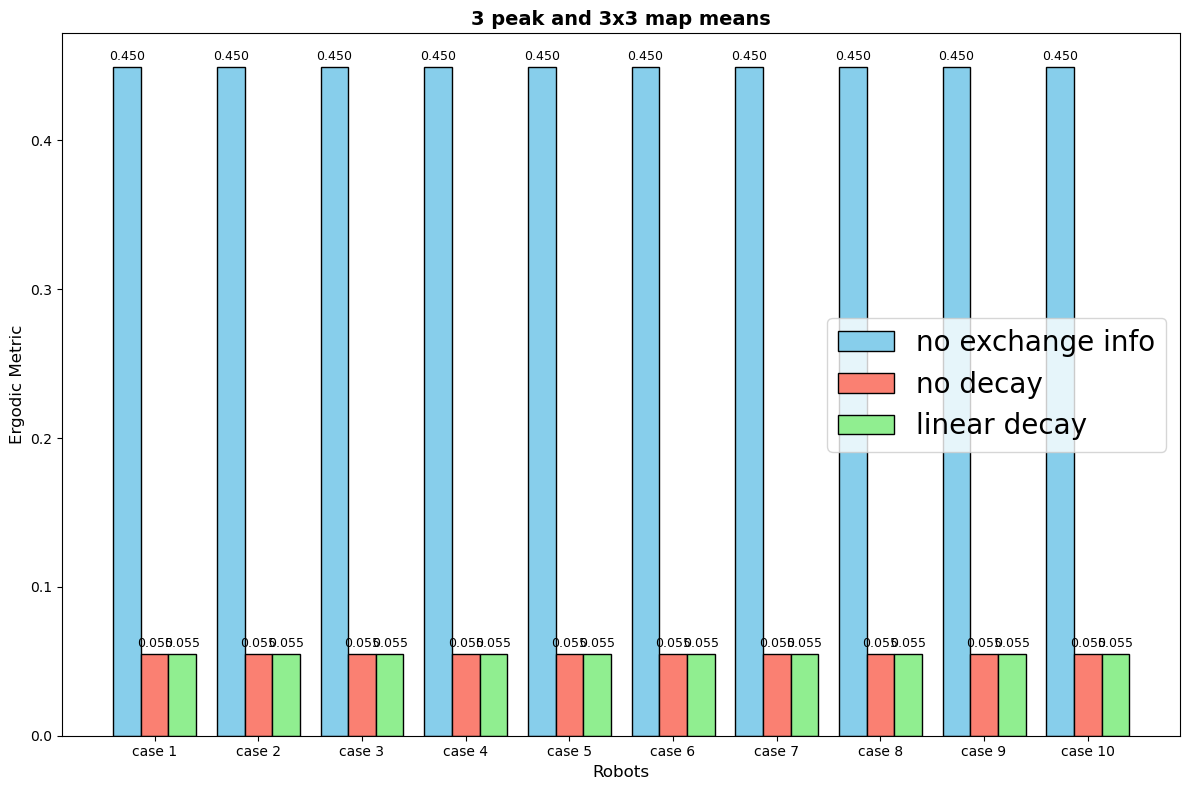

In [2]:
import pandas as pd
from pathlib import Path
import sys 
sys.path.append('..')
from four_robots_lib.plot_utils import plot_hist

# 初始化 datas 为 3x10 的结构：3 行（三种类型），10 列（case1~case10）
datas = [[0.0 for _ in range(10)] for _ in range(3)]
# 定义要提取的类型顺序
types_order = ['noexchange_avg', 'decay_avg', 'nodecay_avg']
# 遍历 case1 到 case10
for i in range(10):
    folder_name = f"../case{i+1}"
    folder_path = Path(folder_name)
    # 查找该文件夹下的 Excel 文件（假设扩展名为 .xlsx）
    excel_files = list(folder_path.glob("*.xlsx"))
    if not excel_files:
        raise FileNotFoundError(f"No Excel file found in {folder_name}")
    if len(excel_files) > 1:
        print(f"Warning: Multiple Excel files in {folder_name}, using the first one.")

    excel_file = excel_files[0]
    df = pd.read_excel(excel_file)

    # 提取三种类型的 metric_mean
    for row_idx, t in enumerate(types_order):
        matched = df[df['type'] == t]
        if not matched.empty:
            datas[row_idx][i] = matched['metric_mean'].iloc[0]
        else:
            datas[row_idx][i] = None  # 或设为 0.0 / NaN 等
            print(f"Warning: '{t}' not found in {excel_file}")

# 读取数据并准备datas
title = "3 peak and 3x3 map means"
save_path = "./hist_means.png"
# 正确调用函数：传递二维的datas
plot_hist(datas, save_path, title)